In [1]:
# 注册到MCP Server
from jupyter_mcp import hook
hook.register(force=True)

✅ Jupyter kernel 已注册到 MCP 服务器
   连接文件: /home/ubuntu/.local/share/jupyter/runtime/kernel-0f8845bb-7cea-460b-8a15-7364f840b45e.json
   Kernel:   graphrag
   模式:     📓 Notebook
   文件:     /home/ubuntu/.openclaw/workspace/Untitled.ipynb
   PID:      2959322

现在可以启动或重启 jupyter-mcp-server.py，它会自动连接到这个 kernel。


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('~/data/Melbourne_housing_FULL.csv')


In [3]:
print("Shape:", df.shape)
print("\n列名 & Dtypes:")
print(df.dtypes.to_string())
print("\n前5行:")
print(df.head().to_string())
print("\n缺失值统计 (缺失数 / 缺失率%):")
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_info = pd.DataFrame({'缺失数': null_counts, '缺失率%': null_pct})
print(null_info[null_info['缺失数'] > 0].to_string())
print("\n数值列描述统计:")
print(df.describe().to_string())
print("\n分类列唯一值数:")
cat_cols = df.select_dtypes(include=['object']).columns
for c in cat_cols:
    print(f"  {c}: {df[c].nunique()} 个唯一值")


Shape: (34857, 21)

列名 & Dtypes:
Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64

前5行:
       Suburb             Address  Rooms Type      Price Method SellerG       Date  Distance  Postcode  Bedroom2  Bathroom  Car  Landsize  BuildingArea  YearBuilt         CouncilArea  Lattitude  Longtitude             Regionname  Propertycount
0  Abbotsford       68 Studley St      2    h        NaN     SS  Jellis  3/09/2016       2.5    3067.0       2.0       1.0  1.0     126.0           NaN        NaN  Yarra City Council   -37.801

LogPrice 正态性检验

1. Shapiro-Wilk (n=5000 子样本)
   Statistic: 0.991945
   P-value:   2.995123e-16
   结论: 不服从正态分布 (p<0.05)

2. D'Agostino-Pearson (Omnibus K^2)
   Statistic: 510.095068
   P-value:   1.714997e-111
   结论: 不服从正态分布 (p<0.05)

3. Kolmogorov-Smirnov (标准化后 vs N(0,1))
   Statistic: 0.038981
   P-value:   2.069770e-36
   结论: 不服从正态分布 (p<0.05)

4. Jarque-Bera
   Statistic: 539.916097
   P-value:   5.737322e-118
   结论: 不服从正态分布 (p<0.05)

5. Anderson-Darling
   Statistic: 53.461763
   临界值 (1%/5%/10%):
     1% → 0.5760  拒绝H0(非正态)
     5% → 0.6560  拒绝H0(非正态)
     10% → 0.7870  拒绝H0(非正态)



=== 偏度/峰度分析 ===
偏度 (Skewness): 0.3359  (有偏)
峰度 (Kurtosis): 0.1561  (接近正态)
标准误偏度 (SE Skew): 0.0148
标准误峰度 (SE Kurt): 0.0297


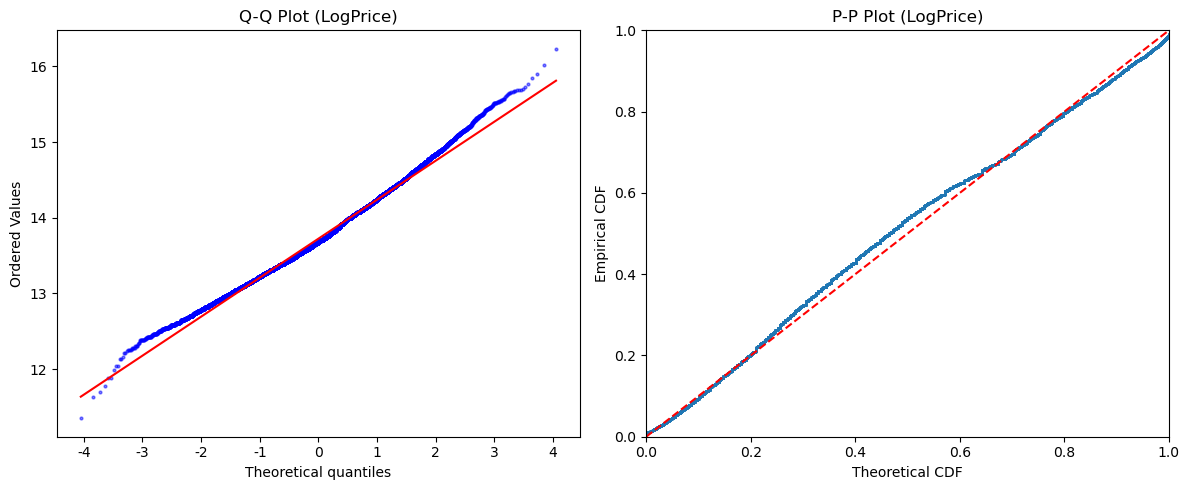

In [14]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

lp = df['LogPrice'].dropna()

# 1. Shapiro-Wilk 检验 (适用于小样本, 这里样本太大可能过于敏感但先做)
# scipy 1.8+ 支持大数据, 但 >5000 时可能很慢, 用随机子集
sw_sample = lp.sample(n=5000, random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sw_sample)

# 2. D'Agostino-Pearson (omnibus K^2) 检验 - 适合大样本
k2_stat, k2_p = stats.normaltest(lp)

# 3. Kolmogorov-Smirnov 检验 (与标准正态对比)
# 需要标准化
lp_std = (lp - lp.mean()) / lp.std()
ks_stat, ks_p = stats.kstest(lp_std, 'norm')

# 4. Jarque-Bera 检验 (偏度峰度联合)
jb_stat, jb_p = stats.jarque_bera(lp)

# 5. Anderson-Darling 检验
ad_result = stats.anderson(lp, dist='norm')

print("=" * 60)
print("LogPrice 正态性检验")
print("=" * 60)

print(f"\n1. Shapiro-Wilk (n=5000 子样本)")
print(f"   Statistic: {shapiro_stat:.6f}")
print(f"   P-value:   {shapiro_p:.6e}")
print(f"   结论: {'服从正态分布' if shapiro_p > 0.05 else '不服从正态分布 (p<0.05)'}")

print(f"\n2. D'Agostino-Pearson (Omnibus K^2)")
print(f"   Statistic: {k2_stat:.6f}")
print(f"   P-value:   {k2_p:.6e}")
print(f"   结论: {'服从正态分布' if k2_p > 0.05 else '不服从正态分布 (p<0.05)'}")

print(f"\n3. Kolmogorov-Smirnov (标准化后 vs N(0,1))")
print(f"   Statistic: {ks_stat:.6f}")
print(f"   P-value:   {ks_p:.6e}")
print(f"   结论: {'服从正态分布' if ks_p > 0.05 else '不服从正态分布 (p<0.05)'}")

print(f"\n4. Jarque-Bera")
print(f"   Statistic: {jb_stat:.6f}")
print(f"   P-value:   {jb_p:.6e}")
print(f"   结论: {'服从正态分布' if jb_p > 0.05 else '不服从正态分布 (p<0.05)'}")

print(f"\n5. Anderson-Darling")
print(f"   Statistic: {ad_result.statistic:.6f}")
print(f"   临界值 (1%/5%/10%):")
for i, sig in enumerate([1, 5, 10]):
    cv = ad_result.critical_values[i]
    print(f"     {sig}% → {cv:.4f}  {'拒绝H0(非正态)' if ad_result.statistic > cv else '不能拒绝H0(正态)'}")

# Q-Q plot 和 P-P plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q Plot
stats.probplot(lp, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot (LogPrice)')
axes[0].get_lines()[0].set_marker('o')
axes[0].get_lines()[0].set_markersize(2)
axes[0].get_lines()[0].set_alpha(0.5)
axes[0].get_lines()[1].set_color('red')

# P-P Plot
from scipy.stats import norm
lp_sorted = np.sort(lp)
lp_cdf = np.linspace(0.01, 0.99, len(lp_sorted))
theoretical_cdf = norm.cdf((lp_sorted - lp.mean()) / lp.std())
axes[1].plot(theoretical_cdf, lp_cdf, 'o', markersize=1, alpha=0.5)
axes[1].plot([0, 1], [0, 1], 'r--')
axes[1].set_title('P-P Plot (LogPrice)')
axes[1].set_xlabel('Theoretical CDF')
axes[1].set_ylabel('Empirical CDF')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 附加：偏度和峰度
print(f"\n=== 偏度/峰度分析 ===")
print(f"偏度 (Skewness): {lp.skew():.4f}  { '(接近0, 对称)' if abs(lp.skew()) < 0.3 else '(有偏)'}")
print(f"峰度 (Kurtosis): {lp.kurtosis():.4f}  { '(接近正态)' if abs(lp.kurtosis()) < 0.5 else '(偏离正态)' }")
print(f"标准误偏度 (SE Skew): {np.sqrt(6/len(lp)):.4f}")
print(f"标准误峰度 (SE Kurt): {np.sqrt(24/len(lp)):.4f}")
